### Required Assignment 3.2: Sorting and Aggregating

**Expected Time**: 60 Minutes

**Total Points**: 10

This activity focuses on sorting the results of a `groupby` operation. The dataset is again the `gapminder` data from plotly.  Your tasks involve aggregating and sorting as well as plotting summary results using `matplotlib`, `seaborn`, and `plotly`.

#### Index:

- [Problem 1](#Problem-1:-Lowest-to-Highest-Average-Life-Expectancy)
- [Problem 2](#Problem-2:-Sorting-GDP)
- [Problem 3](#Problem-3:-Sorting-Results-of-Multiple-Aggregates)
- [Problem 4](#Problem-4:-Sorting-Custom-Outputs)
- [Problem 5](#Problem-5:-Applying-the-\`column_range\`-function)

In [2]:
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
gapminder = px.data.gapminder()

In [4]:
gapminder.head(2)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4


In [5]:
gapminder.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 135.3 KB


[Back to top](#Index:) 

### Problem 1: Highest to Lowest Average Life Expectancy

**2 Points**


Use the `groupby` method on the `gapminder` DataFrame to group the values in the `continent` column. Use a double square bracket notation to apply this operation on the `lifeExp` column. Next, use the pandas function `mean()` to compute the mean value. Finally, use the `sort_values()` function to sort your results by `lifeExp`. Inside the `sort_values()` function, set the `ascending` argument equal to `False`.

Assign your results as a DataFrame to `ans1` below.  

In [6]:
### GRADED

ans1 = None

### BEGIN SOLUTION
ans1 = gapminder.groupby('continent')[['lifeExp']].mean().sort_values(by = 'lifeExp', ascending = False)
### END SOLUTION

# Answer check
print(ans1)
print(type(ans1))

             lifeExp
continent           
Oceania    74.326208
Europe     71.903686
Americas   64.658737
Asia       60.064903
Africa     48.865330
<class 'pandas.DataFrame'>


[Back to top](#Index:) 

### Problem 2: Sorting GDP

**2 Points**

Which country has the highest `gdpPercap`?  Use `groupby` to answer this question and assign your answer as a one-word string representing the name of the country to `ans2` below.

In [7]:
### GRADED

ans2 = None

### BEGIN SOLUTION
ans2 = gapminder.groupby('country')[['gdpPercap']].mean().sort_values(by = 'gdpPercap', ascending = False)
### END SOLUTION
# Answer check
print(ans2)
print(type(ans2))

                  gdpPercap
country                    
Kuwait         65332.910472
Switzerland    27074.334405
Norway         26747.306554
United States  26261.151347
Canada         22410.746340
...                     ...
Mozambique       542.278332
Eritrea          541.002507
Ethiopia         509.115156
Burundi          471.662990
Myanmar          439.333333

[142 rows x 1 columns]
<class 'pandas.DataFrame'>


In [34]:
ans2 = ans2.reset_index()

In [35]:
ans2

,country,gdpPercap
0,Kuwait,65332.910472
1,Switzerland,27074.334405
2,Norway,26747.306554
3,United States,26261.151347
4,Canada,22410.746340
...,...,...
137,Mozambique,542.278332
138,Eritrea,541.002507
139,Ethiopia,509.115156
140,Burundi,471.662990


In [36]:
ans2.loc[0,'country']


'Kuwait'

[Back to top](#Index:) 

### Problem 3: Sorting Results of Multiple Aggregates

**2 Points**

Use the `groupby` method on the `gapminder` DataFrame to group the values in the `continent` column. Next, use the pandas function `agg()` with argument equal to `['mean', 'std', 'median']` to compute the mean, the standard deviation, and the median. Use a double square bracket notation to apply this operation on the `lifeExp` column.  Save this DataFrame to `ans3a` below.  




To sort the resulting values by medians from greatest to least, first flatten and rename the columns using the code:

```python
ans3a.columns = [" ".join(c) for c in ans3a.columns.to_flat_index()]
```


Finally, use the `sort_values` function on `ans3a` to sort the results by `lifeExp median`. Inside the `sort_values` function set the argument `ascending` equal to `False`. Assign your result to `ans3b`.

In [8]:
### GRADED

ans3a = None
ans3b = None

### BEGIN SOLUTION
ans3a = gapminder.groupby('continent')[['lifeExp']].agg(['mean', 'std', 'median'])
ans3a.columns = [" ".join(c) for c in ans3a.columns.to_flat_index()]
ans3b = ans3a.sort_values(by = 'lifeExp median',ascending=False)
### END SOLUTION

# Answer check
print(ans3a)
print(ans3b)

           lifeExp mean  lifeExp std  lifeExp median
continent                                           
Africa        48.865330     9.150210         47.7920
Americas      64.658737     9.345088         67.0480
Asia          60.064903    11.864532         61.7915
Europe        71.903686     5.433178         72.2410
Oceania       74.326208     3.795611         73.6650
           lifeExp mean  lifeExp std  lifeExp median
continent                                           
Oceania       74.326208     3.795611         73.6650
Europe        71.903686     5.433178         72.2410
Americas      64.658737     9.345088         67.0480
Asia          60.064903    11.864532         61.7915
Africa        48.865330     9.150210         47.7920


[Back to top](#Index:) 

### Problem 4: Sorting Custom Outputs

**2 Points**

Complete the definition of the function `column_range` according to the instructions below:

- The `column_range` function should take `col` as input argument.
- The `column_range` function should return the difference between the maximum and the minimum value of `col.


In [9]:
### GRADED

def column_range():
    '''
    This function takes in a pandas series and returns
    the range of the series (max - min) as a float.
    '''
    pass

### BEGIN SOLUTION
def column_range(col):
    return col.max() - col.min()
### END SOLUTION

# Answer check
column_range(gapminder['lifeExp'])

np.float64(59.00399999999999)

[Back to top](#Index:) 

### Problem 5: Applying the `column_range` function

**2 Points**



Use the `groupby` method on the `gapminder` DataFrame to group the values in the `continent` column.  Use a double square bracket notation to apply this operation on the `gdpPercap` column. Next, use the `apply()` function with argument equal to `column_range`. Finally, use the `sort_values()` function to sort the values by `gdpPercap`. Inside the `sort_values()` function, set the argument to `ascending` equal to `False`. Save this DataFrame to `ans5`. below.  

In [10]:
### GRADED

ans5 = None

### BEGIN SOLUTION
ans5 = gapminder.groupby('continent')[['gdpPercap']].apply(column_range).sort_values(by = 'gdpPercap', ascending = False)
### END SOLUTION

# Answer check
ans5

,gdpPercap
continent,
Asia,113192.132900
Europe,48383.656975
Americas,41750.015936
Oceania,24395.771800
Africa,21710.045883


In [11]:
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [12]:
df = gapminder

In [13]:
df.loc[3, 'year']

np.int64(1967)

In [14]:
df.loc[3,'lifeExp']

np.float64(34.02)

In [15]:
df.iloc[3,3]

np.float64(34.02)

In [16]:
num_rows = len(df)

In [17]:
import string

In [18]:
new_index=[]
for i in range(len(df)):
    new_index.append(str(i))

In [19]:
df.index = new_index

In [20]:
df.loc['10','pop']

np.int64(25268405)

In [21]:
df.columns

Index(['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap',
       'iso_alpha', 'iso_num'],
      dtype='str')

<Axes: xlabel='year'>

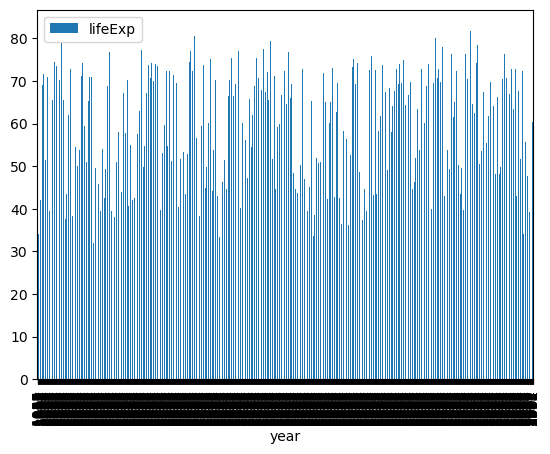

In [22]:
df.plot(kind='bar', x='year', y='lifeExp')

In [23]:
df['year'].head()

0    1952
1    1957
2    1962
3    1967
4    1972
Name: year, dtype: int64

In [24]:
df['lifeExp'].head()

0    28.801
1    30.332
2    31.997
3    34.020
4    36.088
Name: lifeExp, dtype: float64

In [25]:
df.shape


(1704, 8)

In [26]:
d = gapminder.groupby('continent')[['lifeExp']].mean().sort_values(by = 'lifeExp', ascending = False)

In [27]:
d.head()

,lifeExp
continent,
Oceania,74.326208
Europe,71.903686
Americas,64.658737
Asia,60.064903
Africa,48.865330


In [28]:
e = d.reset_index()
e

,continent,lifeExp
0,Oceania,74.326208
1,Europe,71.903686
2,Americas,64.658737
3,Asia,60.064903
4,Africa,48.865330


<Axes: xlabel='continent'>

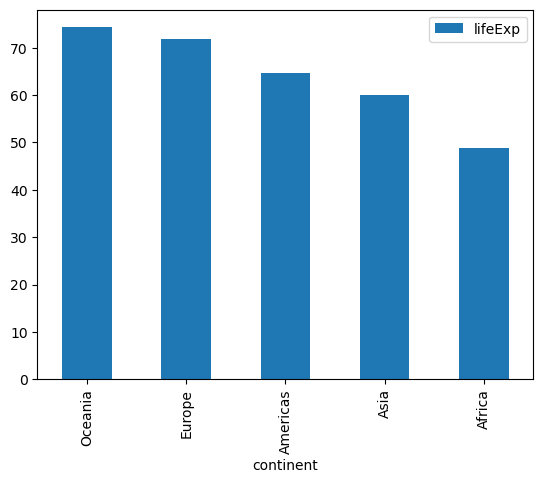

In [29]:
e.plot(kind='bar', x='continent', y='lifeExp')

In [30]:
e.shape

(5, 2)

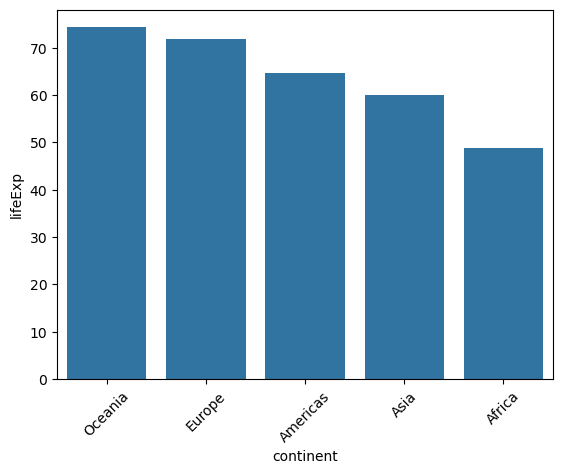

In [31]:


import seaborn as sns
import matplotlib.pyplot as plt



# who v/s fare barplot 
sns.barplot(x = 'continent',
            y = 'lifeExp',
            data = e)

# Show the plot
plt.xticks(rotation=45)
plt.show()

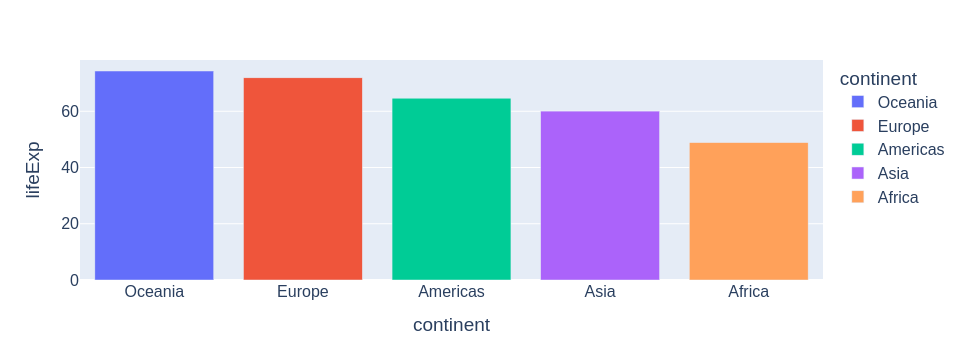

In [32]:
fig=px.bar(e,x="continent", y="lifeExp", color="continent")
fig.update_layout(font_size=16)
fig.show()